***

/lustre/hpc/kemi/kqd720/micromamba/envs/AppML/lib/python3.12/collections/__init__.py:449: ResourceWarning: unclosed <socket.socket [closed] fd=75, family=2, type=1, proto=6>
  result = tuple_new(cls, iterable)


Using device: cpu

Starting Autoencoder training for 10 epochs...


/lustre/hpc/kemi/kqd720/micromamba/envs/AppML/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=2744768) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()



 EPOCH 1/10 	 train loss 0.017980 	 val loss 0.002144


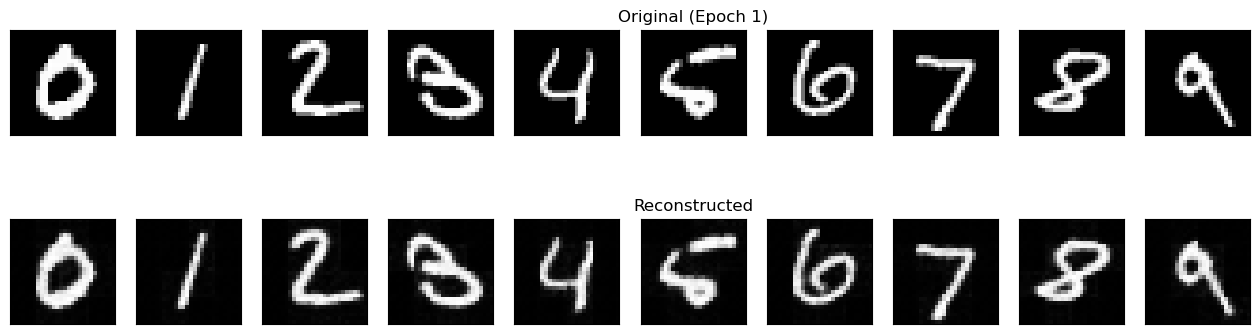


 EPOCH 2/10 	 train loss 0.001651 	 val loss 0.000914


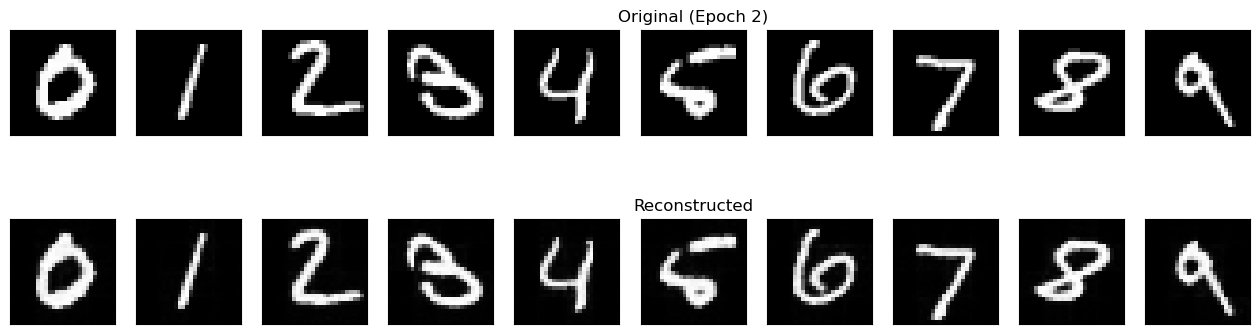


 EPOCH 3/10 	 train loss 0.000962 	 val loss 0.000686


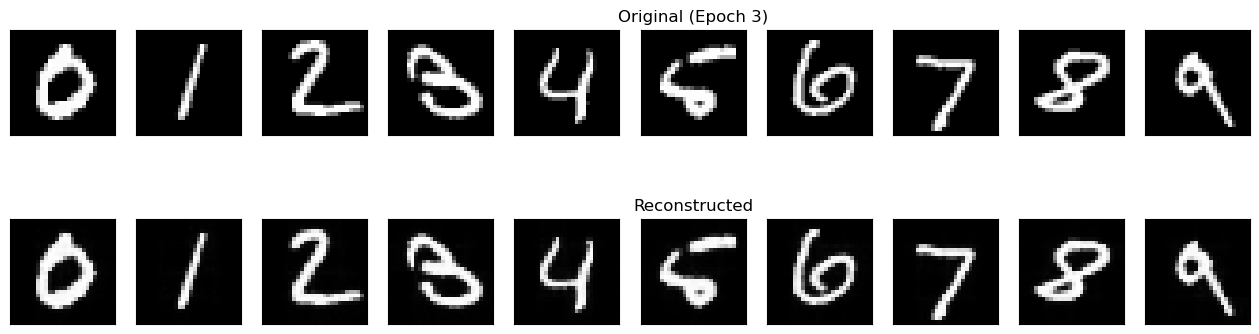


 EPOCH 4/10 	 train loss 0.000760 	 val loss 0.000587


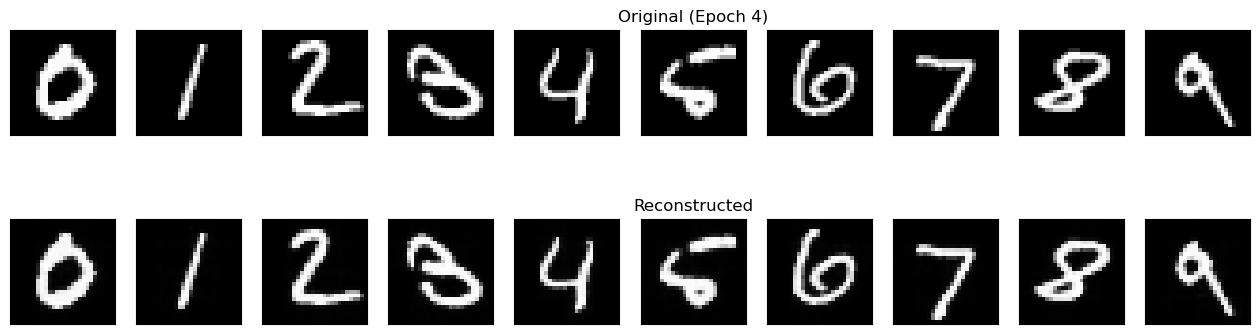


 EPOCH 5/10 	 train loss 0.000655 	 val loss 0.000520


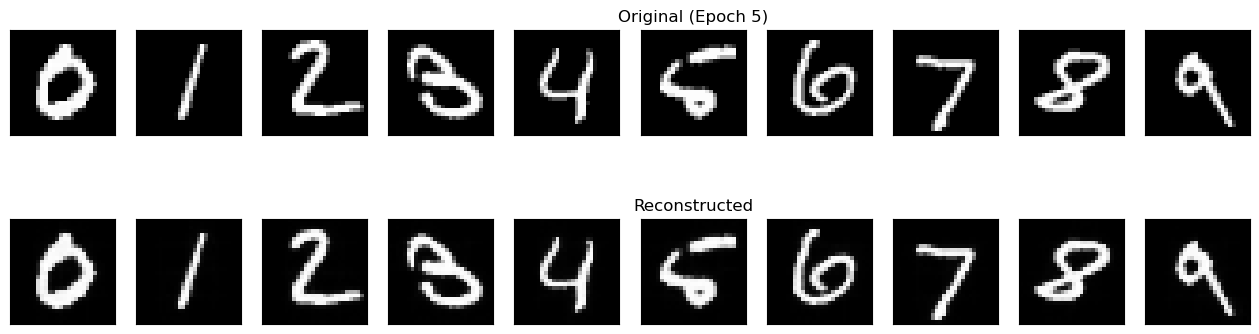


 EPOCH 6/10 	 train loss 0.000582 	 val loss 0.000473


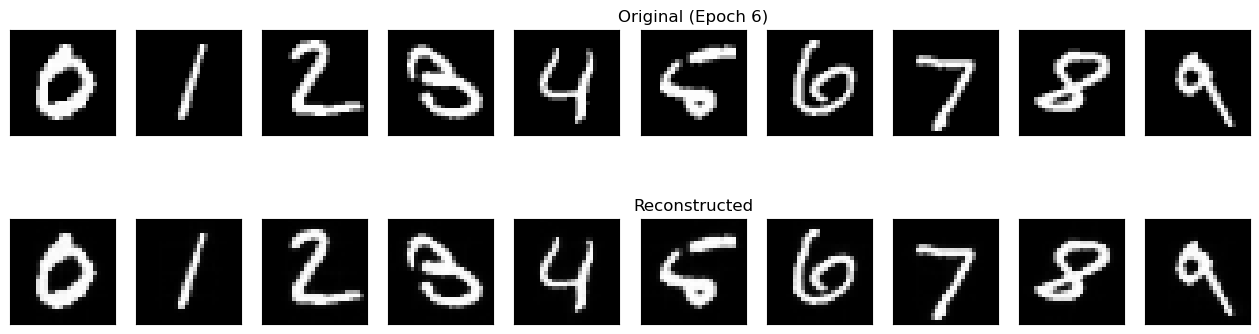


 EPOCH 7/10 	 train loss 0.000530 	 val loss 0.000435


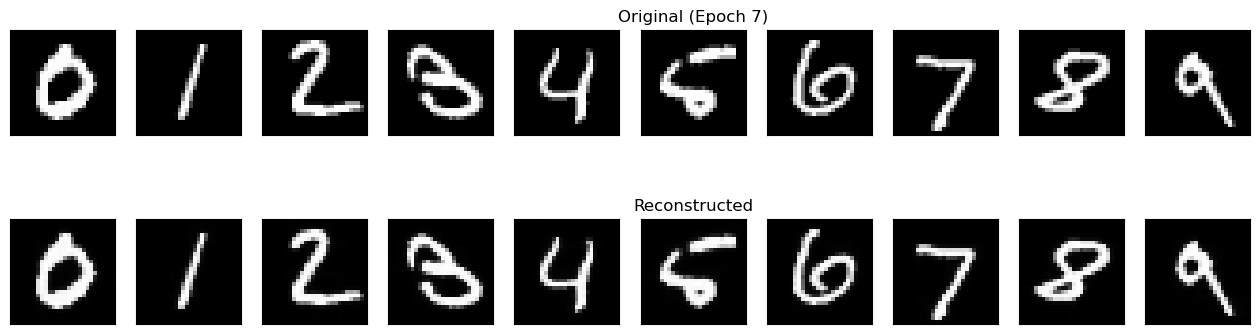


 EPOCH 8/10 	 train loss 0.000490 	 val loss 0.000403


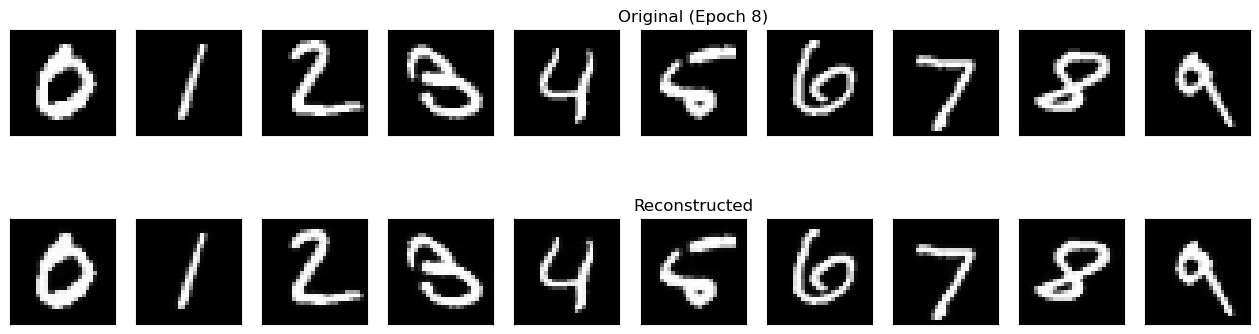


 EPOCH 9/10 	 train loss 0.000455 	 val loss 0.000376


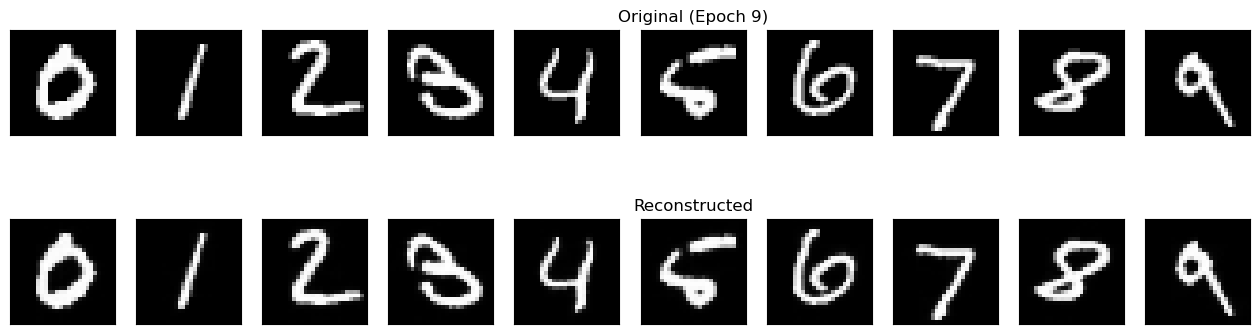


 EPOCH 10/10 	 train loss 0.000423 	 val loss 0.000350


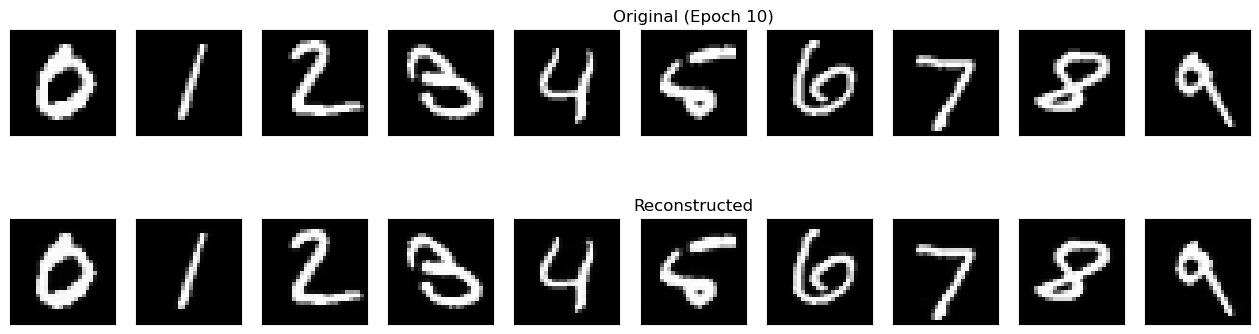

Finished Training.


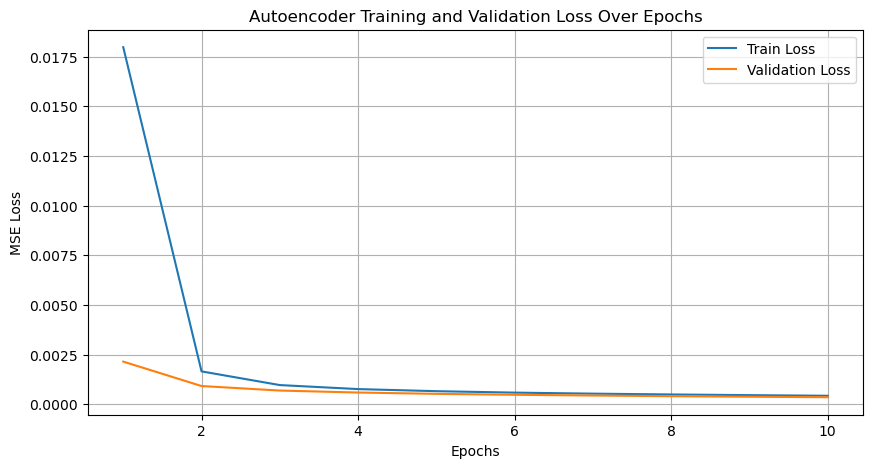

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import random
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Global Stochasticity Control ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# --- Configuration ---
IMG_SIZE = 28
IN_CHANNELS = 1
PATCH_SIZE = 7  # Results in (28/7) * (28/7) = 4 * 4 = 16 patches
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

# Latent dim here refers to the embedding dimension of each patch after encoder/decoder
EMBED_DIM = 64  # Dimension of each patch embedding and latent representation per patch
NUM_HEADS = 4
MLP_RATIO = 4
NUM_ENCODER_BLOCKS = 3 # Number of Transformer encoder layers
NUM_DECODER_BLOCKS = 3 # Number of Transformer decoder layers (can be same as encoder)

BATCH_SIZE = 128
EPOCHS = 10 # Adjusted for potentially longer autoencoder training
LEARNING_RATE = 1e-3

# --- Data Loading and Preprocessing ---
transform = transforms.Compose([
    transforms.ToTensor(), # Converts to [0, 1] tensor. IMPORTANT for MSELoss.
    # No normalization for autoencoder target, usually want to reconstruct original scale.
    # If you do normalize, make sure to denormalize for visualization and potentially for loss.
])

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

train_dataset = torchvision.datasets.MNIST(root='./MNIST', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./MNIST', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, worker_init_fn=seed_worker, generator=g)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, worker_init_fn=seed_worker, generator=g)


# --- Transformer Autoencoder Components ---

class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, x):
        x = self.proj(x)  # (B, E, H/P, W/P)
        x = x.flatten(2)  # (B, E, N_patches)
        x = x.transpose(1, 2)  # (B, N_patches, E)
        return x

class TransformerEncoderModule(nn.Module):
    def __init__(self, num_patches, embed_dim, num_heads, mlp_ratio, num_blocks):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        nn.init.trunc_normal_(self.pos_embed, std=.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * mlp_ratio,
            activation='gelu',
            batch_first=True, # Expects (batch, seq, feature)
            dropout=0.1
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_blocks
        )

    def forward(self, x): # x is (B, N_patches, E) from PatchEmbedding
        x = x + self.pos_embed
        x = self.transformer_encoder(x) # Output is (B, N_patches, E) - our latent sequence
        return x

class TransformerDecoderModule(nn.Module):
    def __init__(self, num_patches, embed_dim, num_heads, mlp_ratio, num_blocks, patch_size, out_channels):
        super().__init__()
        self.num_patches = num_patches
        self.patch_size = patch_size
        self.embed_dim = embed_dim

        # Learnable "decoder" positional embeddings or queries
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        nn.init.trunc_normal_(self.decoder_pos_embed, std=.02)

        # Using TransformerEncoderLayer for simplicity in the decoder as well
        # It will operate on the latent sequence + decoder positional embeddings
        decoder_layer = nn.TransformerEncoderLayer( # Can be nn.TransformerDecoderLayer if you use memory
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * mlp_ratio,
            activation='gelu',
            batch_first=True,
            dropout=0.1
        )
        self.transformer_decoder = nn.TransformerEncoder( # Or nn.TransformerDecoder
            decoder_layer,
            num_layers=num_blocks
        )

        # Project back to patch pixel values
        # Each of the N_patches embeddings of size E needs to be projected to P*P*C
        self.output_projection = nn.Linear(embed_dim, patch_size * patch_size * out_channels)

    def forward(self, x_latent): # x_latent is (B, N_patches, E) from Encoder
        # Add decoder specific positional embeddings to the latent sequence
        # Or, if x_latent was a single vector, you'd use decoder_pos_embed as initial queries
        # and use cross-attention with x_latent as memory.
        # Here, we assume x_latent is already a sequence.
        x = x_latent + self.decoder_pos_embed # Or just self.decoder_pos_embed if latent is global
        x = self.transformer_decoder(x) # (B, N_patches, E)
        x = self.output_projection(x) # (B, N_patches, P*P*C)
        # x now contains the reconstructed flattened patches
        return x

class Unpatchify(nn.Module):
    """
    Reshapes a sequence of flattened patches back into an image.
    """
    def __init__(self, img_size, patch_size, out_channels):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.out_channels = out_channels
        self.num_patches_h = img_size // patch_size
        self.num_patches_w = img_size // patch_size

    def forward(self, x_patches): # x_patches is (B, N_patches, P*P*C)
        batch_size = x_patches.shape[0]
        # Reshape to (B, N_patches, C, P, P) for easier manipulation if C > 1
        # For C=1, (B, N_patches, P*P)
        x_patches = x_patches.view(
            batch_size,
            self.num_patches_h,
            self.num_patches_w,
            self.out_channels,
            self.patch_size,
            self.patch_size
        )
        # Permute to (B, C, H_patches, P_h, W_patches, P_w)
        x_patches = x_patches.permute(0, 3, 1, 4, 2, 5)
        # Reshape to (B, C, H, W)
        reconstructed_img = x_patches.reshape(
            batch_size,
            self.out_channels,
            self.img_size,
            self.img_size
        )
        return reconstructed_img


class TransformerAutoencoder(nn.Module):
    def __init__(self, img_size, patch_size, in_channels,
                 embed_dim, num_heads, mlp_ratio,
                 num_encoder_blocks, num_decoder_blocks):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.n_patches

        self.encoder = TransformerEncoderModule(num_patches, embed_dim, num_heads, mlp_ratio, num_encoder_blocks)
        self.decoder = TransformerDecoderModule(num_patches, embed_dim, num_heads, mlp_ratio, num_decoder_blocks, patch_size, in_channels) # out_channels = in_channels
        self.unpatchify = Unpatchify(img_size, patch_size, in_channels)

        # Sigmoid to ensure output is in [0, 1] range like input
        self.final_activation = nn.Sigmoid()


    def forward(self, img):
        x = self.patch_embed(img)       # (B, N_patches, E)
        latent_seq = self.encoder(x)    # (B, N_patches, E)
        rec_patches = self.decoder(latent_seq) # (B, N_patches, P*P*C)
        rec_img = self.unpatchify(rec_patches) # (B, C, H, W)
        rec_img = self.final_activation(rec_img) # Ensure output in [0,1]
        return rec_img

    # Expose encoder and decoder for the plotting function
    def get_encoder(self):
        return self.encoder # Technically patch_embed + encoder for full encoding path

    def get_decoder(self):
        return self.decoder # Technically decoder + unpatchify for full decoding path

    # Modified forward methods for plot_ae_outputs compatibility
    # These are simplified and assume plot_ae_outputs handles patching/unpatching if needed,
    # or we adapt plot_ae_outputs. Given the provided plot_ae_outputs,
    # it expects separate encoder(img) -> latent and decoder(latent) -> rec_img.
    # The TransformerAutoencoder is a single unit.
    # Let's make internal encoder/decoder steps accessible.

    def encode(self, img):
        patches = self.patch_embed(img)
        return self.encoder(patches)

    def decode(self, latent_seq):
        rec_patches = self.decoder(latent_seq)
        rec_img = self.unpatchify(rec_patches)
        rec_img = self.final_activation(rec_img)
        return rec_img


# --- Model, Loss, Optimizer ---
# We need separate encoder and decoder instances for plot_ae_outputs if used directly
# OR, we pass the autoencoder model and call its encode/decode methods within plot_ae_outputs
autoencoder_model = TransformerAutoencoder(
    img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=IN_CHANNELS,
    embed_dim=EMBED_DIM, num_heads=NUM_HEADS, mlp_ratio=MLP_RATIO,
    num_encoder_blocks=NUM_ENCODER_BLOCKS, num_decoder_blocks=NUM_DECODER_BLOCKS
).to(DEVICE)

loss_fn = nn.MSELoss()
optimizer = optim.AdamW(autoencoder_model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# --- Plotting Function (as provided) ---
def plot_ae_outputs(model_ae, current_epoch, n=10, dataset=test_dataset):
    plt.figure(figsize=(16,4.5))
    targets = dataset.targets.numpy()
    # Get unique targets and take the first n if available
    unique_targets = np.unique(targets)
    display_targets = unique_targets[:n]
    if len(display_targets) < n:
        print(f"Warning: Only {len(display_targets)} unique digits found for plotting, requested {n}.")
        n = len(display_targets) # Adjust n if not enough unique digits


    t_idx = {i:np.where(targets==i)[0][0] for i in display_targets}


    for i_idx, digit_val in enumerate(display_targets):
        ax = plt.subplot(2,n,i_idx+1)
        # Get specific image for the digit
        img_tensor, _ = dataset[t_idx[digit_val]]
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE) # Add batch dim and move to device

        model_ae.eval() # Set model to evaluation mode
        with torch.no_grad():
            # Use the model's encode and decode methods
            latent_representation = model_ae.encode(img_tensor)
            rec_img = model_ae.decode(latent_representation)

        plt.imshow(img_tensor.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i_idx == n//2:
            ax.set_title(f'Original (Epoch {current_epoch+1})')

        ax = plt.subplot(2, n, i_idx + 1 + n)
        plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if i_idx == n//2:
            ax.set_title('Reconstructed')
    plt.show()


# --- Training and Evaluation Epoch Functions for Autoencoder ---
def train_epoch_ae(model, dataloader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    total_samples = 0
    for images, _ in dataloader: # Labels are not used for AE training
        images = images.to(device)
        optimizer.zero_grad()
        reconstructed_images = model(images)
        loss = loss_fn(reconstructed_images, images) # Compare reconstruction with original
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        total_samples += images.size(0)
    epoch_loss = running_loss / total_samples
    return epoch_loss

def test_epoch_ae(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            reconstructed_images = model(images)
            loss = loss_fn(reconstructed_images, images)
            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
    epoch_loss = running_loss / total_samples
    return epoch_loss

# --- Lists to store metrics for plotting ---
diz_loss = {'train_loss':[], 'val_loss':[]}

# --- Main Training Loop ---
print(f"\nStarting Autoencoder training for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    train_loss = train_epoch_ae(autoencoder_model, train_loader, loss_fn, optimizer, DEVICE)
    val_loss = test_epoch_ae(autoencoder_model, test_loader, loss_fn, DEVICE)
    print(f'\n EPOCH {epoch + 1}/{EPOCHS} \t train loss {train_loss:.6f} \t val loss {val_loss:.6f}')

    diz_loss['train_loss'].append(train_loss)
    diz_loss['val_loss'].append(val_loss)

    # Visualize reconstructions at the end of each epoch
    plot_ae_outputs(autoencoder_model, current_epoch=epoch, n=10, dataset=test_dataset)

print("Finished Training.")

# Plotting overall loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), diz_loss['train_loss'], label='Train Loss')
plt.plot(range(1, EPOCHS + 1), diz_loss['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()